In [1]:
!pip install --no-cache-dir "gymnasium[atari,accept-rom-license]"
!pip install torch torchvision
!pip install opencv-python matplotlib
!pip uninstall -y gymnasium ale-py
!pip install gymnasium==1.1.1 ale-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of shimmy[atari] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 70.8 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.29.0
    Uninstalling gymnasium-0.29.0:
      Successfully uninstalled gymnasium-0.29.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stable-baselines3 2.1.0 requires gymnasium<0.30,>=0.28.1, but you have gymnasium 1.2.3 which is incompatible.
kaggle-environments 1.18.0 requires gymnasium==0.29.0, but you have gymnasium 1.2.3 which is incompat

In [2]:



import gymnasium as gym
import ale_py  # REQUIRED: Import ale-py for Atari environments
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import random
import cv2
from dataclasses import dataclass
from typing import Tuple, List, Optional
import os


# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Quick environment check
try:
    _test_env = gym.make("ALE/Seaquest-v5")
    print(f"✓ Seaquest environment available ({_test_env.action_space.n} actions)")
    _test_env.close()
except Exception as e:
    print(f"✗ Environment error: {e}")
    print("  Run: pip install 'gymnasium[atari]'")

# =============================================================================
# CELL 2: Configuration Class
# =============================================================================

Using device: cuda
✓ Seaquest environment available (18 actions)


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [3]:
@dataclass
class DQNConfig:
    """
    Configuration for DQN hyperparameters.
    Centralizes all tunable parameters for easy experimentation.
    """
    # Environment
    env_name: str = "ALE/Seaquest-v5"
    
    # Training
    total_episodes: int = 5000
    total_test_episodes: int = 100
    max_steps_per_episode: int = 10000
    
    # DQN hyperparameters
    learning_rate: float = 0.00025      # Alpha in Bellman equation
    gamma: float = 0.99                  # Discount factor
    
    # Exploration (epsilon-greedy)
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.00001
    
    # Experience replay
    buffer_size: int = 100000
    batch_size: int = 32
    min_buffer_size: int = 10000
    
    # Target network
    target_update_freq: int = 1000
    
    # Frame preprocessing
    frame_height: int = 84
    frame_width: int = 84
    frame_stack: int = 4
    
    # Logging
    save_freq: int = 500
    log_freq: int = 10
    
    def to_dict(self) -> dict:
        return {k: v for k, v in self.__dict__.items()}

In [4]:
# =============================================================================
# CELL 3: Frame Preprocessing
# =============================================================================

class FramePreprocessor:
    """
    Preprocesses Atari frames for the DQN.
    
    Converts RGB frames to grayscale, resizes to 84x84, and normalizes.
    
    Attribution: Preprocessing approach adapted from DeepMind's DQN paper
    (Mnih et al., 2015) and OpenAI Baselines.
    """
    
    def __init__(self, height: int = 84, width: int = 84):
        self.height = height
        self.width = width
    
    def preprocess(self, frame: np.ndarray) -> np.ndarray:
        """
        Preprocess a single frame.
        
        Args:
            frame: Raw RGB frame (210, 160, 3)
            
        Returns:
            Processed grayscale frame (84, 84)
        """
        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        
        # Resize
        resized = cv2.resize(gray, (self.width, self.height), 
                            interpolation=cv2.INTER_AREA)
        
        # Normalize to [0, 1]
        normalized = resized.astype(np.float32) / 255.0
        
        return normalized


class FrameStacker:
    """
    Stacks consecutive frames to capture temporal information.
    
    Stacking frames allows the network to perceive motion and velocity.
    """
    
    def __init__(self, stack_size: int = 4):
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)
    
    def reset(self, initial_frame: np.ndarray) -> np.ndarray:
        """Reset stack with initial frame repeated."""
        self.frames.clear()
        for _ in range(self.stack_size):
            self.frames.append(initial_frame)
        return self._get_stacked()
    
    def add_frame(self, frame: np.ndarray) -> np.ndarray:
        """Add new frame and return stacked frames."""
        self.frames.append(frame)
        return self._get_stacked()
    
    def _get_stacked(self) -> np.ndarray:
        return np.stack(self.frames, axis=0)

In [5]:
# =============================================================================
# CELL 4: Experience Replay Buffer
# =============================================================================

Experience = namedtuple('Experience', 
                        ['state', 'action', 'reward', 'next_state', 'done'])


class ReplayBuffer:
    """
    Experience replay buffer for storing and sampling transitions.
    
    Experience replay breaks correlation between consecutive samples
    and improves learning stability.
    
    Attribution: Concept from Mnih et al., 2013. Implementation is original.
    """
    
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state: np.ndarray, action: int, reward: float, 
             next_state: np.ndarray, done: bool) -> None:
        """Add experience to buffer."""
        self.buffer.append(Experience(state, action, reward, next_state, done))
    
    def sample(self, batch_size: int) -> List[Experience]:
        """Sample random batch of experiences."""
        return random.sample(self.buffer, batch_size)
    
    def __len__(self) -> int:
        return len(self.buffer)

In [6]:
# =============================================================================
# CELL 5: Neural Network Architecture
# =============================================================================

class DQN(nn.Module):
    """
    Deep Q-Network with convolutional layers for Atari frames.
    
    Architecture:
        - 3 convolutional layers for feature extraction
        - 2 fully connected layers for Q-value estimation
        - Output: Q-value for each possible action
    
    Attribution: Architecture based on DeepMind's Nature paper (Mnih et al., 2015).
    PyTorch implementation is original.
    """
    
    def __init__(self, input_shape: Tuple[int, int, int], n_actions: int):
        """
        Args:
            input_shape: (channels, height, width) - typically (4, 84, 84)
            n_actions: Number of possible actions
        """
        super(DQN, self).__init__()
        
        self.input_shape = input_shape
        self.n_actions = n_actions
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # Calculate conv output size
        conv_out_size = self._get_conv_output_size(input_shape)
        
        # Fully connected layers
        self.fc1 = nn.Linear(conv_out_size, 512)
        self.fc2 = nn.Linear(512, n_actions)
    
    def _get_conv_output_size(self, shape: Tuple[int, int, int]) -> int:
        """Calculate output size after conv layers."""
        dummy = torch.zeros(1, *shape)
        out = self._forward_conv(dummy)
        return int(np.prod(out.shape[1:]))
    
    def _forward_conv(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return x
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Args:
            x: Input state (batch, channels, height, width)
            
        Returns:
            Q-values for each action (batch, n_actions)
        """
        x = self._forward_conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
# =============================================================================
# CELL 6: DQN Agent
# =============================================================================

class DQNAgent:
    """
    Deep Q-Learning Agent for Atari games.
    
    Implements DQN with:
        - Experience replay
        - Target network
        - Epsilon-greedy exploration
    
    The Q-learning update follows the Bellman equation:
        Q(s,a) = Q(s,a) + α * (r + γ * max_a' Q(s',a') - Q(s,a))
    """
    
    def __init__(self, config: DQNConfig):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Initialize environment
        self.env = gym.make(config.env_name, render_mode="rgb_array")
        self.n_actions = self.env.action_space.n
        
        print(f"Environment: {config.env_name}")
        print(f"Action space: {self.n_actions} actions")
        print(f"Device: {self.device}")
        
        # Preprocessing
        self.preprocessor = FramePreprocessor(config.frame_height, config.frame_width)
        self.frame_stacker = FrameStacker(config.frame_stack)
        
        # State shape
        self.state_shape = (config.frame_stack, config.frame_height, config.frame_width)
        
        # Networks
        self.policy_net = DQN(self.state_shape, self.n_actions).to(self.device)
        self.target_net = DQN(self.state_shape, self.n_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        # Optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), 
                                    lr=config.learning_rate)
        
        # Replay buffer
        self.replay_buffer = ReplayBuffer(config.buffer_size)
        
        # Tracking
        self.total_steps = 0
        self.epsilon = config.epsilon_start
        self.episode_rewards = []
        self.episode_lengths = []
        self.losses = []
        self.epsilons = []
    
    def select_action(self, state: np.ndarray) -> int:
        """Select action using epsilon-greedy policy."""
        # Update epsilon
        self.epsilon = self.config.epsilon_end + \
            (self.config.epsilon_start - self.config.epsilon_end) * \
            np.exp(-self.config.epsilon_decay * self.total_steps)
        
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()
    
    def optimize(self) -> Optional[float]:
        """Perform one optimization step."""
        if len(self.replay_buffer) < self.config.min_buffer_size:
            return None
        
        # Sample batch
        experiences = self.replay_buffer.sample(self.config.batch_size)
        batch = Experience(*zip(*experiences))
        
        # Convert to tensors
        states = torch.FloatTensor(np.array(batch.state)).to(self.device)
        actions = torch.LongTensor(batch.action).to(self.device)
        rewards = torch.FloatTensor(batch.reward).to(self.device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(self.device)
        dones = torch.BoolTensor(batch.done).to(self.device)
        
        # Current Q-values
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))
        
        # Target Q-values
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (self.config.gamma * next_q * ~dones)
        
        # Loss
        loss = F.smooth_l1_loss(current_q.squeeze(), target_q)
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()
        
        return loss.item()
    
    def update_target_network(self) -> None:
        """Copy weights to target network."""
        self.target_net.load_state_dict(self.policy_net.state_dict())
    
    def train_episode(self) -> Tuple[float, int]:
        """Train for one episode."""
        obs, _ = self.env.reset()
        processed = self.preprocessor.preprocess(obs)
        state = self.frame_stacker.reset(processed)
        
        total_reward = 0
        episode_length = 0
        
        for step in range(self.config.max_steps_per_episode):
            # Select and perform action
            action = self.select_action(state)
            next_obs, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            
            # Preprocess
            processed_next = self.preprocessor.preprocess(next_obs)
            next_state = self.frame_stacker.add_frame(processed_next)
            
            # Store experience
            self.replay_buffer.push(state, action, reward, next_state, done)
            
            # Optimize
            loss = self.optimize()
            if loss is not None:
                self.losses.append(loss)
            
            # Update target network
            if self.total_steps % self.config.target_update_freq == 0:
                self.update_target_network()
            
            state = next_state
            total_reward += reward
            episode_length += 1
            self.total_steps += 1
            
            if done:
                break
        
        self.episode_rewards.append(total_reward)
        self.episode_lengths.append(episode_length)
        self.epsilons.append(self.epsilon)
        
        return total_reward, episode_length
    
    def train(self) -> dict:
        """Main training loop."""
        print(f"\nStarting training for {self.config.total_episodes} episodes...")
        
        for episode in range(1, self.config.total_episodes + 1):
            reward, length = self.train_episode()
            
            if episode % self.config.log_freq == 0:
                avg_reward = np.mean(self.episode_rewards[-self.config.log_freq:])
                avg_length = np.mean(self.episode_lengths[-self.config.log_freq:])
                print(f"Episode {episode}/{self.config.total_episodes} | "
                      f"Reward: {reward:.1f} | Avg: {avg_reward:.1f} | "
                      f"Length: {avg_length:.1f} | ε: {self.epsilon:.4f}")
            
            if episode % self.config.save_freq == 0:
                self.save_model(f"model_ep{episode}.pth")
        
        return self._get_metrics()
    
    def test(self, n_episodes: int = 10, render: bool = False) -> dict:
        """Test the trained agent."""
        render_mode = "human" if render else "rgb_array"
        test_env = gym.make(self.config.env_name, render_mode=render_mode)
        
        self.policy_net.eval()
        rewards, lengths = [], []
        
        for ep in range(n_episodes):
            obs, _ = test_env.reset()
            processed = self.preprocessor.preprocess(obs)
            state = self.frame_stacker.reset(processed)
            
            total_reward = 0
            length = 0
            
            while True:
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    action = self.policy_net(state_tensor).argmax().item()
                
                next_obs, reward, term, trunc, _ = test_env.step(action)
                done = term or trunc
                
                processed_next = self.preprocessor.preprocess(next_obs)
                state = self.frame_stacker.add_frame(processed_next)
                
                total_reward += reward
                length += 1
                
                if done:
                    break
            
            rewards.append(total_reward)
            lengths.append(length)
            print(f"Test Episode {ep + 1}: Reward = {total_reward}")
        
        test_env.close()
        self.policy_net.train()
        
        return {
            "mean_reward": np.mean(rewards),
            "std_reward": np.std(rewards),
            "mean_length": np.mean(lengths),
            "rewards": rewards
        }
    
    def _get_metrics(self) -> dict:
        return {
            "episode_rewards": self.episode_rewards,
            "episode_lengths": self.episode_lengths,
            "losses": self.losses,
            "epsilons": self.epsilons,
            "total_steps": self.total_steps
        }
    
    def save_model(self, filename: str) -> None:
        os.makedirs("checkpoints", exist_ok=True)
        torch.save({
            "policy_net": self.policy_net.state_dict(),
            "target_net": self.target_net.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "total_steps": self.total_steps,
            "config": self.config.to_dict()
        }, f"checkpoints/{filename}")
        print(f"Saved: checkpoints/{filename}")
    
    def load_model(self, filename: str) -> None:
        checkpoint = torch.load(f"checkpoints/{filename}", map_location=self.device)
        self.policy_net.load_state_dict(checkpoint["policy_net"])
        self.target_net.load_state_dict(checkpoint["target_net"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.total_steps = checkpoint["total_steps"]
        print(f"Loaded: checkpoints/{filename}")



if __name__ == "__main__":
    # Quick test with minimal episodes
    config = DQNConfig(
        total_episodes=10,
        log_freq=1
    )
    
    agent = DQNAgent(config)
    metrics = agent.train()
    
    print("\n--- Training Complete ---")
    print(f"Final reward: {metrics['episode_rewards'][-1]}")
    print(f"Total steps: {metrics['total_steps']}")

Environment: ALE/Seaquest-v5
Action space: 18 actions
Device: cuda

Starting training for 10 episodes...
Episode 1/10 | Reward: 0.0 | Avg: 0.0 | Length: 395.0 | ε: 0.9961
Episode 2/10 | Reward: 120.0 | Avg: 120.0 | Length: 552.0 | ε: 0.9907
Episode 3/10 | Reward: 20.0 | Avg: 20.0 | Length: 419.0 | ε: 0.9866
Episode 4/10 | Reward: 160.0 | Avg: 160.0 | Length: 753.0 | ε: 0.9793
Episode 5/10 | Reward: 80.0 | Avg: 80.0 | Length: 515.0 | ε: 0.9743
Episode 6/10 | Reward: 100.0 | Avg: 100.0 | Length: 509.0 | ε: 0.9694
Episode 7/10 | Reward: 200.0 | Avg: 200.0 | Length: 839.0 | ε: 0.9614
Episode 8/10 | Reward: 140.0 | Avg: 140.0 | Length: 751.0 | ε: 0.9542
Episode 9/10 | Reward: 100.0 | Avg: 100.0 | Length: 617.0 | ε: 0.9484
Episode 10/10 | Reward: 20.0 | Avg: 20.0 | Length: 391.0 | ε: 0.9448

--- Training Complete ---
Final reward: 20.0
Total steps: 5741


In [8]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
from datetime import datetime
import json
import os


baseline_config = DQNConfig(
    # Environment
    env_name="ALE/Seaquest-v5",
    
    # Training duration
    total_episodes=5000,           # As specified in assignment
    total_test_episodes=100,       # As specified in assignment
    max_steps_per_episode=10000,
    
    # Core DQN parameters
    learning_rate=0.00025,         # Alpha - standard for Adam + DQN
    gamma=0.99,                    # Discount factor - high for long-term planning
    
    # Exploration schedule
    epsilon_start=1.0,             # Start fully random
    epsilon_end=0.01,              # End with 1% exploration
    epsilon_decay=0.00001,         # Exponential decay rate
    
    # Experience replay
    buffer_size=100000,
    batch_size=32,
    min_buffer_size=10000,         # Wait before training starts
    
    # Target network
    target_update_freq=1000,
    
    # Preprocessing
    frame_height=84,
    frame_width=84,
    frame_stack=4,
    
    # Logging
    save_freq=500,
    log_freq=10
)

print("Baseline Configuration:")
print("-" * 40)
for key, value in baseline_config.to_dict().items():
    print(f"  {key}: {value}")

# =============================================================================
# CELL 3: Run Baseline Training
# =============================================================================

print("\n" + "="*60)
print("BASELINE TRAINING")
print("="*60)

# Create agent
baseline_agent = DQNAgent(baseline_config)

# Train
baseline_metrics = baseline_agent.train()

# Save final model
baseline_agent.save_model("baseline_final.pth")

# =============================================================================
# CELL 4: Baseline Test Performance
# =============================================================================

Baseline Configuration:
----------------------------------------
  env_name: ALE/Seaquest-v5
  total_episodes: 5000
  total_test_episodes: 100
  max_steps_per_episode: 10000
  learning_rate: 0.00025
  gamma: 0.99
  epsilon_start: 1.0
  epsilon_end: 0.01
  epsilon_decay: 1e-05
  buffer_size: 100000
  batch_size: 32
  min_buffer_size: 10000
  target_update_freq: 1000
  frame_height: 84
  frame_width: 84
  frame_stack: 4
  save_freq: 500
  log_freq: 10

BASELINE TRAINING
Environment: ALE/Seaquest-v5
Action space: 18 actions
Device: cuda

Starting training for 5000 episodes...
Episode 10/5000 | Reward: 100.0 | Avg: 58.0 | Length: 494.4 | ε: 0.9523
Episode 20/5000 | Reward: 160.0 | Avg: 34.0 | Length: 440.3 | ε: 0.9117
Episode 30/5000 | Reward: 80.0 | Avg: 86.0 | Length: 595.9 | ε: 0.8595
Episode 40/5000 | Reward: 100.0 | Avg: 156.0 | Length: 691.3 | ε: 0.8028
Episode 50/5000 | Reward: 200.0 | Avg: 170.0 | Length: 684.8 | ε: 0.7503
Episode 60/5000 | Reward: 160.0 | Avg: 144.0 | Length: 686.

In [9]:
# =============================================================================
# CELL 5: Performance Metrics Analysis
# =============================================================================



def analyze_performance(metrics: dict) -> dict:
    """Compute detailed performance statistics."""
    rewards = np.array(metrics['episode_rewards'])
    lengths = np.array(metrics['episode_lengths'])
    
    # Split into phases
    n = len(rewards)
    early = slice(0, n // 5)           # First 20%
    mid = slice(n // 5, 4 * n // 5)    # Middle 60%
    late = slice(4 * n // 5, n)        # Last 20%
    
    analysis = {
        "overall": {
            "mean_reward": float(np.mean(rewards)),
            "std_reward": float(np.std(rewards)),
            "max_reward": float(np.max(rewards)),
            "mean_length": float(np.mean(lengths)),
            "std_length": float(np.std(lengths)),
            "total_steps": metrics['total_steps']
        },
        "early_training": {
            "mean_reward": float(np.mean(rewards[early])),
            "mean_length": float(np.mean(lengths[early]))
        },
        "mid_training": {
            "mean_reward": float(np.mean(rewards[mid])),
            "mean_length": float(np.mean(lengths[mid]))
        },
        "late_training": {
            "mean_reward": float(np.mean(rewards[late])),
            "mean_length": float(np.mean(lengths[late]))
        },
        "final_epsilon": metrics['epsilons'][-1] if metrics['epsilons'] else None
    }
    
    return analysis

baseline_analysis = analyze_performance(baseline_metrics)

print("\n" + "="*60)
print("PERFORMANCE ANALYSIS")
print("="*60)

print("\nOverall Statistics:")
for key, value in baseline_analysis['overall'].items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

print("\nTraining Phases:")
print(f"  Early (ep 1-{baseline_config.total_episodes//5}):")
print(f"    Avg Reward: {baseline_analysis['early_training']['mean_reward']:.2f}")
print(f"    Avg Length: {baseline_analysis['early_training']['mean_length']:.2f}")

print(f"  Mid (ep {baseline_config.total_episodes//5}-{4*baseline_config.total_episodes//5}):")
print(f"    Avg Reward: {baseline_analysis['mid_training']['mean_reward']:.2f}")
print(f"    Avg Length: {baseline_analysis['mid_training']['mean_length']:.2f}")

print(f"  Late (ep {4*baseline_config.total_episodes//5}-{baseline_config.total_episodes}):")
print(f"    Avg Reward: {baseline_analysis['late_training']['mean_reward']:.2f}")
print(f"    Avg Length: {baseline_analysis['late_training']['mean_length']:.2f}")


PERFORMANCE ANALYSIS

Overall Statistics:
  mean_reward: 307.3480
  std_reward: 133.8531
  max_reward: 940.0000
  mean_length: 944.2422
  std_length: 379.2281
  total_steps: 4721211

Training Phases:
  Early (ep 1-1000):
    Avg Reward: 189.12
    Avg Length: 842.95
  Mid (ep 1000-4000):
    Avg Reward: 330.28
    Avg Length: 964.16
  Late (ep 4000-5000):
    Avg Reward: 356.78
    Avg Length: 985.76


In [10]:
print("\n" + "="*60)
print("BASELINE TESTING")
print("="*60)

test_results = baseline_agent.test(n_episodes=100)

print(f"\nTest Results:")
print(f"  Mean Reward: {test_results['mean_reward']:.2f} ± {test_results['std_reward']:.2f}")
print(f"  Mean Length: {test_results['mean_length']:.2f}")


BASELINE TESTING
Test Episode 1: Reward = 220.0
Test Episode 2: Reward = 440.0
Test Episode 3: Reward = 320.0
Test Episode 4: Reward = 220.0
Test Episode 5: Reward = 320.0
Test Episode 6: Reward = 440.0
Test Episode 7: Reward = 340.0
Test Episode 8: Reward = 320.0
Test Episode 9: Reward = 180.0
Test Episode 10: Reward = 320.0
Test Episode 11: Reward = 520.0
Test Episode 12: Reward = 360.0
Test Episode 13: Reward = 240.0
Test Episode 14: Reward = 320.0
Test Episode 15: Reward = 220.0
Test Episode 16: Reward = 320.0
Test Episode 17: Reward = 260.0
Test Episode 18: Reward = 280.0
Test Episode 19: Reward = 160.0
Test Episode 20: Reward = 280.0
Test Episode 21: Reward = 360.0
Test Episode 22: Reward = 460.0
Test Episode 23: Reward = 460.0
Test Episode 24: Reward = 320.0
Test Episode 25: Reward = 360.0
Test Episode 26: Reward = 260.0
Test Episode 27: Reward = 260.0
Test Episode 28: Reward = 340.0
Test Episode 29: Reward = 640.0
Test Episode 30: Reward = 240.0
Test Episode 31: Reward = 320.0

Saved plot to results/baseline_metrics.png


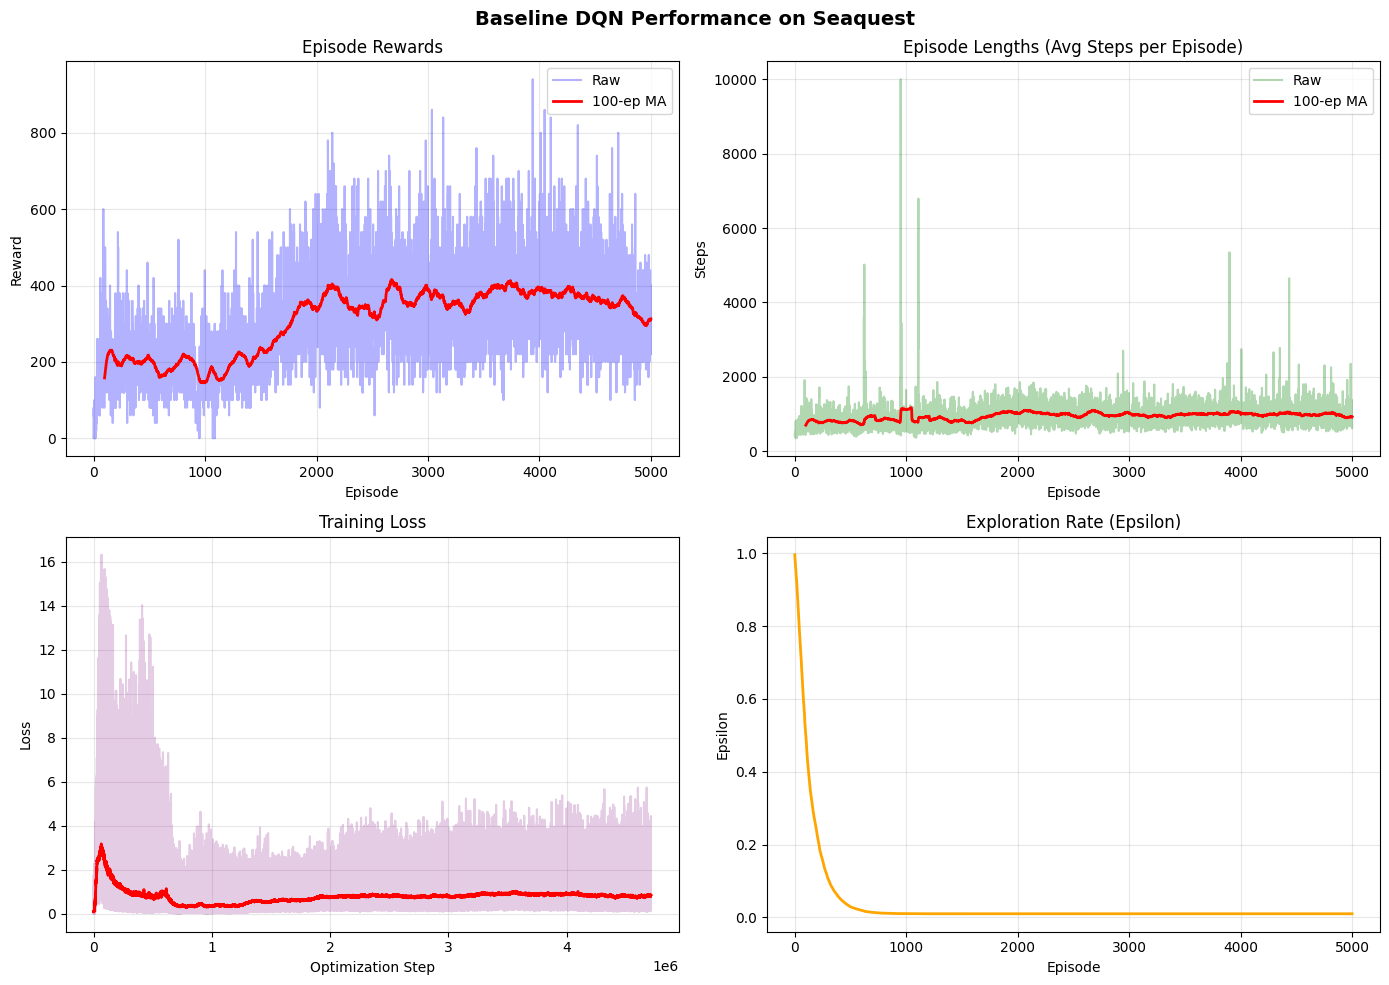


Results saved to results/baseline_results.json

BASELINE SUMMARY (for documentation)

BASELINE PERFORMANCE RESULTS

Configuration:
- Environment: ALE/Seaquest-v5
- Episodes: 5000
- Learning Rate (α): 0.00025
- Discount Factor (γ): 0.99
- Epsilon: 1.0 → 0.01
- Decay Rate: 1e-05

Training Results:
- Mean Reward: 307.35
- Max Reward: 940.00
- Mean Episode Length: 944.24
- Total Steps: 4721211

Test Results (100 episodes):
- Mean Reward: 319.20 ± 88.54

Epsilon at Final Episode: 0.010000

Learning Progression:
- Early Training Avg Reward: 189.12
- Late Training Avg Reward: 356.78
- Improvement: 167.66



In [11]:
# =============================================================================
# CELL 6: Visualization
# =============================================================================

def plot_baseline_metrics(metrics: dict, save_path: str = None):
    """Create comprehensive visualization of baseline performance."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Baseline DQN Performance on Seaquest', fontsize=14, fontweight='bold')
    
    # Episode Rewards
    ax1 = axes[0, 0]
    rewards = metrics['episode_rewards']
    ax1.plot(rewards, alpha=0.3, color='blue', label='Raw')
    
    # Moving average
    window = 100
    if len(rewards) > window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax1.plot(range(window-1, len(rewards)), ma, 
                color='red', linewidth=2, label=f'{window}-ep MA')
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.set_title('Episode Rewards')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Episode Lengths
    ax2 = axes[0, 1]
    lengths = metrics['episode_lengths']
    ax2.plot(lengths, alpha=0.3, color='green', label='Raw')
    
    if len(lengths) > window:
        ma = np.convolve(lengths, np.ones(window)/window, mode='valid')
        ax2.plot(range(window-1, len(lengths)), ma,
                color='red', linewidth=2, label=f'{window}-ep MA')
    
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Steps')
    ax2.set_title('Episode Lengths (Avg Steps per Episode)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Training Loss
    ax3 = axes[1, 0]
    if metrics['losses']:
        losses = metrics['losses']
        ax3.plot(losses, alpha=0.2, color='purple')
        
        loss_window = min(1000, len(losses) // 10) or 1
        if len(losses) > loss_window:
            ma = np.convolve(losses, np.ones(loss_window)/loss_window, mode='valid')
            ax3.plot(range(loss_window-1, len(losses)), ma, color='red', linewidth=2)
    
    ax3.set_xlabel('Optimization Step')
    ax3.set_ylabel('Loss')
    ax3.set_title('Training Loss')
    ax3.grid(True, alpha=0.3)
    
    # Epsilon Decay
    ax4 = axes[1, 1]
    ax4.plot(metrics['epsilons'], color='orange', linewidth=2)
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('Epsilon')
    ax4.set_title('Exploration Rate (Epsilon)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    
    plt.show()

# Plot
plot_baseline_metrics(baseline_metrics, save_path='results/baseline_metrics.png')

# =============================================================================
# CELL 7: Save Results
# =============================================================================

# Save analysis to JSON
os.makedirs('results', exist_ok=True)

results_to_save = {
    "config": baseline_config.to_dict(),
    "analysis": baseline_analysis,
    "test_results": {
        "mean_reward": test_results['mean_reward'],
        "std_reward": test_results['std_reward'],
        "mean_length": test_results['mean_length']
    },
    "timestamp": datetime.now().isoformat()
}

with open('results/baseline_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("\nResults saved to results/baseline_results.json")

# =============================================================================
# CELL 8: Summary for Report
# =============================================================================

print("\n" + "="*60)
print("BASELINE SUMMARY (for documentation)")
print("="*60)

print(f"""
BASELINE PERFORMANCE RESULTS
============================

Configuration:
- Environment: {baseline_config.env_name}
- Episodes: {baseline_config.total_episodes}
- Learning Rate (α): {baseline_config.learning_rate}
- Discount Factor (γ): {baseline_config.gamma}
- Epsilon: {baseline_config.epsilon_start} → {baseline_config.epsilon_end}
- Decay Rate: {baseline_config.epsilon_decay}

Training Results:
- Mean Reward: {baseline_analysis['overall']['mean_reward']:.2f}
- Max Reward: {baseline_analysis['overall']['max_reward']:.2f}
- Mean Episode Length: {baseline_analysis['overall']['mean_length']:.2f}
- Total Steps: {baseline_analysis['overall']['total_steps']}

Test Results (100 episodes):
- Mean Reward: {test_results['mean_reward']:.2f} ± {test_results['std_reward']:.2f}

Epsilon at Final Episode: {baseline_analysis['final_epsilon']:.6f}

Learning Progression:
- Early Training Avg Reward: {baseline_analysis['early_training']['mean_reward']:.2f}
- Late Training Avg Reward: {baseline_analysis['late_training']['mean_reward']:.2f}
- Improvement: {baseline_analysis['late_training']['mean_reward'] - baseline_analysis['early_training']['mean_reward']:.2f}
""")